# Awakening of the Gyroscope: โมเดลจำแนกกิจกรรมจากชุดข้อมูล Kaggle

โมเดลจำแนกกิจกรรมของมนุษย์ 6 แบบ (เดิน ขึ้นบันได ลงบันได นั่ง ยืน นอน) จากข้อมูลเซนเซอร์สมาร์ทโฟนด้วยพีชคณิตเชิงเส้น โดยใช้ PCA ในการลดมิติข้อมูล และใช้วิธี Nearest Centroid ในการจำแนกกิจกรรม

โมเดลสร้างจากชุดข้อมูลที่เผยแพร่บน Kaggle ซึ่งประกอบด้วยข้อมูล train จำนวน 7,352 แถว และข้อมูล test จำนวน 2,947 แถว แถวละ 561 ฟีเจอร์

**วิธีใช้งาน:** จัดเก็บไฟล์นี้ไว้ในโฟลเดอร์เดียวกับ `train.csv` และ `test.csv` จากนั้นรันทุกเซลล์ตามลำดับจากบนลงล่าง

## การนำเข้าข้อมูล

แต่ละไฟล์ประกอบด้วย 563 คอลัมน์ ได้แก่ ฟีเจอร์ 561 คอลัมน์ คอลัมน์ `subject` (อาสาสมัคร) และคอลัมน์ `Activity` (กิจกรรมจริง)

- `Xtr` และ `Xte` คือเมทริกซ์ข้อมูลของชุด train และชุด test ตามลำดับ โดยข้อมูล 1 แถวคือเวกเตอร์ 1 ตัวใน ℝ⁵⁶¹ และแต่ละฟีเจอร์เป็นสเกลาร์ 1 ค่า
- `ytr` และ `yte` คือกิจกรรมจริงของข้อมูลแต่ละแถว จัดเก็บเป็นตัวเลข 0–5 ตามลำดับใน `NAMES`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

NAMES = ["เดิน", "ขึ้นบันได", "ลงบันได", "นั่ง", "ยืน", "นอน"]
CODE = {"WALKING": 0, "WALKING_UPSTAIRS": 1, "WALKING_DOWNSTAIRS": 2,
        "SITTING": 3, "STANDING": 4, "LAYING": 5}

Xtr = train.iloc[:, :561].to_numpy()          # ข้อมูล train (7352 × 561)
ytr = train["Activity"].map(CODE).to_numpy()  # กิจกรรมจริงของ train
Xte = test.iloc[:, :561].to_numpy()           # ข้อมูล test (2947 × 561)
yte = test["Activity"].map(CODE).to_numpy()   # กิจกรรมจริงของ test (ใช้ตรวจคำตอบเท่านั้น)

print("train:", Xtr.shape)
print("test: ", Xte.shape)

Matplotlib is building the font cache; this may take a moment.


train: (7352, 561)
test:  (2947, 561)


## การสร้างโมเดลจากข้อมูล train

### 1. หาค่าเฉลี่ยของข้อมูล

คำนวณค่าเฉลี่ยของแต่ละฟีเจอร์ ได้เวกเตอร์ค่าเฉลี่ย μ ซึ่งมีสมาชิก 561 ค่า

In [2]:
mu = Xtr.mean(axis=0)
print("ขนาดของ μ:", mu.shape)

ขนาดของ μ: (561,)


### 2. Centering

x̃ = x − μ

นำข้อมูลทุกแถวลบด้วยเวกเตอร์ค่าเฉลี่ย μ เพื่อย้ายจุดกลางของข้อมูลไปที่ 0

In [3]:
Xc = Xtr - mu
print("ค่าเฉลี่ยหลัง centering ที่ห่างจาก 0 มากที่สุด:", abs(Xc.mean(axis=0)).max())

ค่าเฉลี่ยหลัง centering ที่ห่างจาก 0 มากที่สุด: 1.935339810064745e-16


### 3. Covariance matrix

C = X̃ᵀX̃ ÷ (n − 1)

ได้เมทริกซ์สมมาตรขนาด 561 × 561 ใช้วัดการกระจายของแต่ละฟีเจอร์ และความสัมพันธ์ระหว่างฟีเจอร์

In [4]:
n = len(Xc)
C = Xc.T @ Xc / (n - 1)
print("ขนาดของ C:", C.shape)
print("C สมมาตร:", np.allclose(C, C.T))

ขนาดของ C: (561, 561)
C สมมาตร: True


### 4–5. หา eigenvalue และ eigenvector

eigenvalue ได้จากสมการลักษณะเฉพาะ det(C − λI) = 0 และ eigenvector ได้จากการแก้ระบบสมการ (C − λI)v = 0 เนื่องจาก C มีขนาด 561 × 561 จึงใช้ฟังก์ชัน `np.linalg.eigh` ในการหาคำตอบของสมการดังกล่าว

- `lam` คือ eigenvalue (λ) ซึ่งบอกปริมาณ variance ตามทิศของ eigenvector โดยเรียงลำดับจากมากไปน้อย
- `V` คือเมทริกซ์ของ eigenvector โดยคอลัมน์ที่ i คู่กับ `lam[i]` และทุกคอลัมน์เป็นเวกเตอร์หนึ่งหน่วย

In [5]:
lam, V = np.linalg.eigh(C)
order = np.argsort(lam)[::-1]        # เรียงจากมากไปน้อย
lam, V = lam[order], V[:, order]

print("eigenvalue 5 ตัวแรก:", lam[:5].round(4))
print("ตรวจสอบ Cv = λv ของตัวแรก:", np.allclose(C @ V[:, 0], lam[0] * V[:, 0]))
print("ความยาวของ eigenvector ตัวแรก:", round(float(np.linalg.norm(V[:, 0])), 4))

eigenvalue 5 ตัวแรก: [34.8236  2.735   2.2944  1.0438  0.9435]
ตรวจสอบ Cv = λv ของตัวแรก: True
ความยาวของ eigenvector ตัวแรก: 1.0


### การเลือกจำนวนแกน k

explained variance ratio = (λ₁ + … + λₖ) ÷ Σλ

เลือกค่า k ที่น้อยที่สุดที่ทำให้ explained variance ratio สะสมได้อย่างน้อย 95% จากนั้นนำ eigenvector k ตัวแรกมาจัดเรียงเป็นเมทริกซ์ W ขนาด 561 × k โดยแต่ละคอลัมน์เป็น eigenvector

In [6]:
ratio = np.cumsum(lam) / lam.sum()        # explained variance สะสม
k = int(np.argmax(ratio >= 0.95)) + 1     # ตัวแรกที่ถึง 95%
W = V[:, :k]

print("k =", k)
print(f"explained variance สะสมที่ k แกน = {ratio[k-1]:.2%}")
print("ขนาดของ W:", W.shape)

k = 67
explained variance สะสมที่ k แกน = 95.05%
ขนาดของ W: (561, 67)


### 6. ฉายข้อมูลลง k มิติ

Z = X̃ · W

ฉายข้อมูลทั้งชุดลงบน subspace k มิติพร้อมกัน เพื่อลดมิติข้อมูลจาก 561 เหลือ k มิติ

In [7]:
Z = Xc @ W
print("ขนาดของ Z:", Z.shape)

ขนาดของ Z: (7352, 67)


### 7. หา centroid ของแต่ละกิจกรรม

คำนวณค่าเฉลี่ยของ Z ในแต่ละกิจกรรม ได้จุดตัวแทน (centroid) ของกิจกรรมนั้น รวม 6 จุด แต่ละจุดเป็นเวกเตอร์ k มิติ

In [8]:
centroids = np.array([Z[ytr == a].mean(axis=0) for a in range(6)])
print("ขนาดของ centroids:", centroids.shape)

ขนาดของ centroids: (6, 67)


โมเดลที่ได้ประกอบด้วย 3 ส่วน ได้แก่ `mu`, `W` และ `centroids`

## 8. ใช้โมเดลทำนายข้อมูล test ทั้งชุด

ข้อมูล test เป็นข้อมูลใหม่ที่โมเดลไม่ทราบคำตอบ การทำนายใช้เฉพาะ μ, W และ centroid จากข้อ 1–7 โดยดำเนินการกับข้อมูลทุกแถวพร้อมกันตามขั้นตอนต่อไปนี้

1. ลบ μ: x̃ = x − μ
2. ฉายข้อมูล: z = x̃ · W
3. วัดระยะด้วย Euclidean distance จาก z ไปยัง centroid ของทั้ง 6 กิจกรรม แล้วเลือกกิจกรรมที่มีระยะน้อยที่สุด (Nearest Centroid)

In [9]:
def distances(X):
    """ระยะจากแต่ละแถวของ X ถึง centroid ทั้ง 6 กิจกรรม"""
    Znew = (X - mu) @ W
    return np.linalg.norm(Znew[:, None, :] - centroids[None, :, :], axis=2)

def predict(X):
    """ทายกิจกรรมของแต่ละแถว (เลข 0–5)"""
    return distances(X).argmin(axis=1)

pred = predict(Xte)
print("จำนวนแถวที่ทาย:", len(pred))

จำนวนแถวที่ทาย: 2947


## ผลลัพธ์

### Confusion matrix และ Accuracy

สร้างเมทริกซ์ขนาด 6 × 6 เปรียบเทียบกิจกรรมจริงกับกิจกรรมที่ทำนาย โดยแถวแทนกิจกรรมจริง และคอลัมน์แทนกิจกรรมที่ทำนาย

Accuracy = ผลรวมแนวทแยง (trace) ÷ ผลรวมทั้งเมทริกซ์

In [10]:
cm = np.zeros((6, 6), dtype=int)
for t, p in zip(yte, pred):
    cm[t, p] += 1

acc = np.trace(cm) / cm.sum()
print(f"ทายถูก {np.trace(cm):,} จาก {cm.sum():,} แถว")
print(f"Accuracy = {acc:.2%}")

pd.DataFrame(cm, index=NAMES, columns=NAMES).rename_axis(index="จริง", columns="ทาย")

ทายถูก 2,480 จาก 2,947 แถว
Accuracy = 84.15%


ทาย,เดิน,ขึ้นบันได,ลงบันได,นั่ง,ยืน,นอน
จริง,,,,,,
เดิน,438,8,50,0,0,0
ขึ้นบันได,22,427,22,0,0,0
ลงบันได,101,59,260,0,0,0
นั่ง,0,3,0,357,131,0
ยืน,0,1,0,69,462,0
นอน,0,1,0,0,0,536


### กราฟแสดงผล

เซลล์ถัดไปกำหนดค่าฟอนต์เพื่อให้กราฟแสดงผลภาษาไทยได้

In [11]:
from matplotlib import font_manager

have = {f.name for f in font_manager.fontManager.ttflist}
for name in ["Thonburi", "Tahoma", "Ayuthaya", "Leelawadee UI", "Loma"]:
    if name in have:
        plt.rcParams["font.family"] = name
        break

plt.rcParams["axes.unicode_minus"] = False     # ให้เครื่องหมายลบแสดงได้กับฟอนต์ไทย
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
BLUE, GRAY = "#2a78d6", "#d3d2cc"

**กราฟที่ 1: Explained variance สะสม** แสดงจำนวนแกนที่ต้องใช้เพื่อให้ explained variance ratio สะสมได้อย่างน้อย 95%

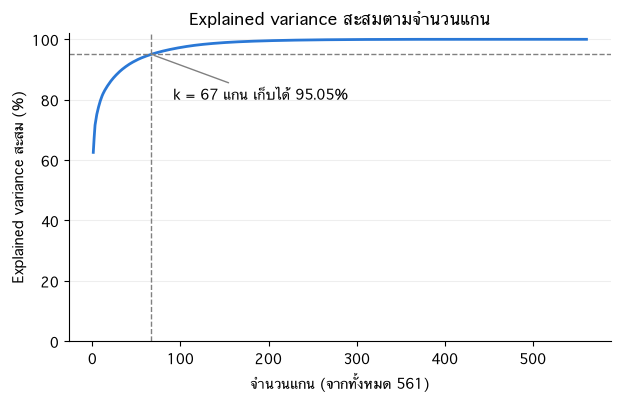

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ratio) + 1), ratio * 100, color=BLUE, linewidth=2)
ax.axhline(95, color="gray", linestyle="--", linewidth=1)
ax.axvline(k, color="gray", linestyle="--", linewidth=1)
ax.annotate(f"k = {k} แกน เก็บได้ {ratio[k-1]:.2%}", xy=(k, 95), xytext=(k + 25, 80),
            arrowprops=dict(arrowstyle="-", color="gray"))
ax.set_xlabel("จำนวนแกน (จากทั้งหมด 561)")
ax.set_ylabel("Explained variance สะสม (%)")
ax.set_title("Explained variance สะสมตามจำนวนแกน")
ax.set_ylim(0, 102)
ax.grid(axis="y", color="#eeeeee")
plt.show()

**กราฟที่ 2: ข้อมูล train บนแกน PC1 และ PC2** แสดงแยกตามกิจกรรม โดยจุดสีน้ำเงินแทนกิจกรรมที่ระบุในหัวข้อของแต่ละภาพ และจุดสีเทาแทนกิจกรรมอื่น

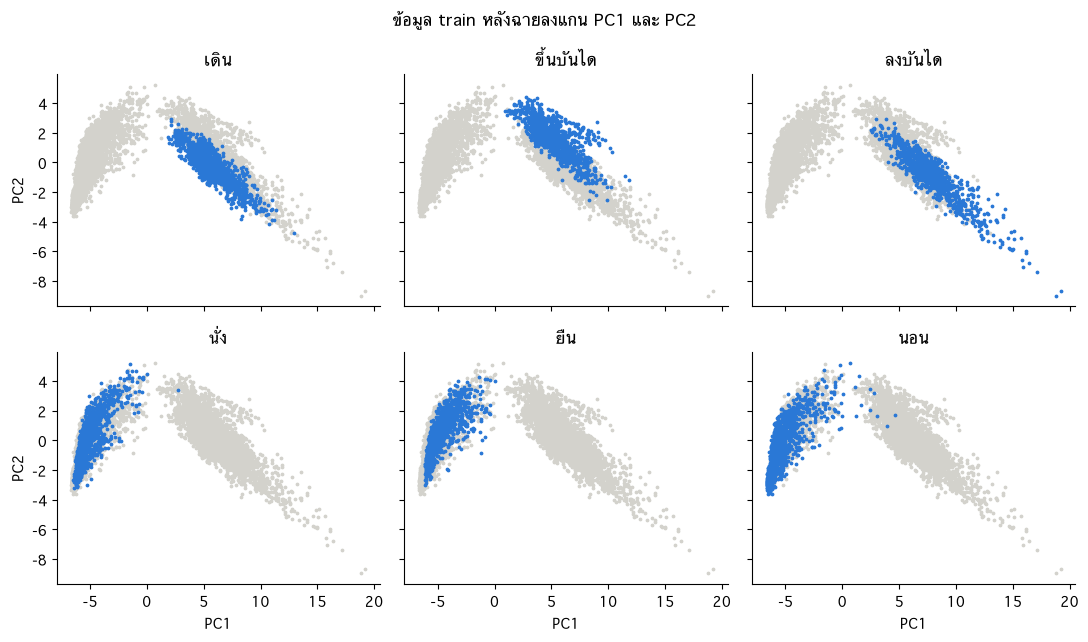

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)
for a, ax in enumerate(axes.flat):
    ax.scatter(Z[ytr != a, 0], Z[ytr != a, 1], s=3, color=GRAY)
    ax.scatter(Z[ytr == a, 0], Z[ytr == a, 1], s=3, color=BLUE)
    ax.set_title(NAMES[a])
for ax in axes[1]:
    ax.set_xlabel("PC1")
for ax in axes[:, 0]:
    ax.set_ylabel("PC2")
fig.suptitle("ข้อมูล train หลังฉายลงแกน PC1 และ PC2")
plt.tight_layout()
plt.show()

**กราฟที่ 3: Confusion matrix** ช่องในแนวทแยงแสดงจำนวนข้อมูลที่ทำนายถูกต้อง ส่วนช่องอื่นแสดงจำนวนข้อมูลที่ทำนายผิด

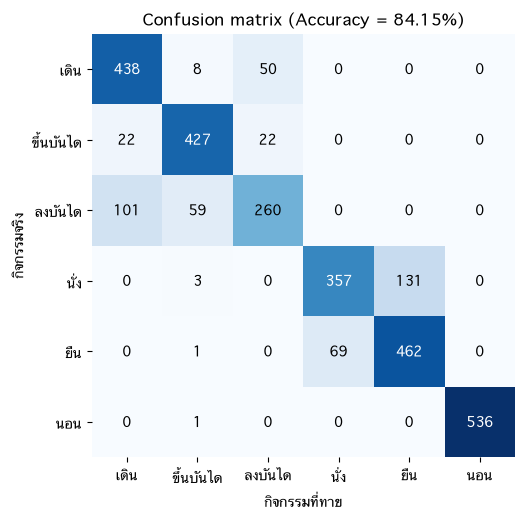

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(6), NAMES)
ax.set_yticks(range(6), NAMES)
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("กิจกรรมที่ทาย")
ax.set_ylabel("กิจกรรมจริง")
ax.set_title(f"Confusion matrix (Accuracy = {acc:.2%})")
ax.spines[:].set_visible(False)
plt.show()

## การทำนายข้อมูลทีละแถว (สำหรับการสาธิต)

ระบุลำดับแถวของ `test.csv` โดยนับเฉพาะแถวข้อมูล ไม่นับแถวหัวตาราง และเริ่มนับจาก 1

ผลลัพธ์แสดงระยะจากข้อมูลแถวนั้นไปยัง centroid ของทั้ง 6 กิจกรรม กิจกรรมที่โมเดลทำนาย และกิจกรรมจริง

In [15]:
def show_row(row):
    i = row - 1
    d = distances(Xte[i:i+1])[0]          # ระยะถึง centroid ทั้ง 6
    p = d.argmin()                        # กิจกรรมที่ระยะน้อยที่สุด
    print(f"แถวที่ {row} ของ test.csv")
    print("ระยะถึง centroid:")
    for a in range(6):
        print(f"   {NAMES[a]:<10} {d[a]:8.4f}" + ("   <-- น้อยที่สุด" if a == p else ""))
    print("โมเดลทายว่า:", NAMES[p])
    print("คำตอบจริง:  ", NAMES[yte[i]], "(ทายถูก)" if p == yte[i] else "(ทายผิด)")

show_row(81)

แถวที่ 81 ของ test.csv
ระยะถึง centroid:
   เดิน         3.2513   <-- น้อยที่สุด
   ขึ้นบันได    4.1408
   ลงบันได      5.2718
   นั่ง        10.1138
   ยืน          9.8100
   นอน         10.6644
โมเดลทายว่า: เดิน
คำตอบจริง:   เดิน (ทายถูก)


In [21]:
show_row(40)      # เปลี่ยนเลขแถวได้ ตั้งแต่ 1 ถึง 2947

แถวที่ 40 ของ test.csv
ระยะถึง centroid:
   เดิน        12.0023
   ขึ้นบันได   11.7912
   ลงบันได     14.1153
   นั่ง         2.7298   <-- น้อยที่สุด
   ยืน          2.8607
   นอน          5.1144
โมเดลทายว่า: นั่ง
คำตอบจริง:   นั่ง (ทายถูก)
